# 01 — Data Understanding

## E-Commerce Risk & Demand Intelligence System

**Scope of this notebook:** exploration only.

This notebook inspects `nigeria_ecommerce_major_project_25000.csv` as-is. It does **not**:

- train any model,
- permanently clean or overwrite the source data,
- drop rows,
- engineer or encode features,
- assume what the cancellation target or feature set will be.

Any parsed/derived columns created below (e.g. a datetime version of `order_timestamp`) exist only in memory for this notebook and are not written back to the CSV.

Decisions about targets, leakage rules, and modeling strategy are owned by the project's engineer and are **not** made in this notebook. The final section lists open questions that must be resolved before any modeling work begins.


## 1. Imports and Data Load

We load the CSV using a project-relative path (no hard-coded absolute paths), so the notebook works whether it is run from the repository root or from within `notebook/`.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

input_root = Path("/kaggle/input")
target_file = "nigeria_ecommerce_major_project_25000.csv"

if not input_root.exists():
    raise RuntimeError(
        "This cell must run on Kaggle, not the local VS Code kernel. "
        "Push the notebook with 'kaggle kernels push -p .' and run it on Kaggle."
    )

dataset_path = next(input_root.rglob(target_file), None)

if dataset_path is None:
    raise FileNotFoundError(
        f"{target_file} was not found under {input_root}. "
        "Confirm that the Kaggle dataset is attached to this Kernel."
    )

print(f"Using Kaggle dataset: {dataset_path}")
df = pd.read_csv(dataset_path)
df.head()

In [1]:
# Imports and reproducibility setup
from pathlib import Path
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings("ignore")



df = pd.read_csv('../data/nigeria_ecommerce_25000.csv')

print("Shape:", df.shape)
display(df.head())

Shape: (25000, 31)


,order_id,customer_id,order_timestamp,order_date,city,customer_type,customer_tenure_days,previous_orders,prior_cancellations,email_verified,...,shipping_fee,delivery_distance_km,estimated_delivery_days,payment_method,gross_amount,discount_amount,total_amount,order_status,actual_delivery_days,customer_rating
0,1,13681,2024-03-06 05:49:07,2024-03-06,Ilorin,New,6,0,0,True,...,1900.0,25.4,4,Card,8500.0,850.0,9550.0,Delivered,5.0,4.0
1,2,12075,2025-07-19 18:17:04,2025-07-19,Benin City,Returning,402,14,0,True,...,1900.0,25.4,5,Card,264800.0,26480.0,240220.0,Delivered,7.0,4.0
2,3,10402,2025-04-23 11:48:09,2025-04-23,Abuja,Returning,221,5,0,True,...,2500.0,38.3,5,Bank Transfer,54600.0,0.0,57100.0,Delivered,6.0,4.0
3,4,10764,2024-11-16 19:40:59,2024-11-16,Port Harcourt,Returning,178,13,1,False,...,2100.0,28.6,5,Cash on Delivery,238800.0,11940.0,228960.0,Delivered,6.0,3.0
4,5,11214,2024-11-12 12:49:09,2024-11-12,Port Harcourt,New,82,0,0,True,...,2400.0,34.9,5,Bank Transfer,11600.0,1160.0,12840.0,Cancelled,NaN,NaN


## 2. Dataframe Shape


In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 25,000
Columns: 31


**Why this matters:** confirms the file loaded correctly and matches the expected row/column count documented for this dataset. A mismatch here (e.g. far fewer rows than expected) is an early signal of a truncated file, a wrong delimiter, or an encoding issue — all of which must be resolved before any further analysis is trusted.


## 3. First 10 Rows and a Fixed-Seed Random Sample


In [3]:
display(df.head(10))

,order_id,customer_id,order_timestamp,order_date,city,customer_type,customer_tenure_days,previous_orders,prior_cancellations,email_verified,...,shipping_fee,delivery_distance_km,estimated_delivery_days,payment_method,gross_amount,discount_amount,total_amount,order_status,actual_delivery_days,customer_rating
0,1,13681,2024-03-06 05:49:07,2024-03-06,Ilorin,New,6,0,0,True,...,1900.0,25.4,4,Card,8500.0,850.0,9550.0,Delivered,5.0,4.0
1,2,12075,2025-07-19 18:17:04,2025-07-19,Benin City,Returning,402,14,0,True,...,1900.0,25.4,5,Card,264800.0,26480.0,240220.0,Delivered,7.0,4.0
2,3,10402,2025-04-23 11:48:09,2025-04-23,Abuja,Returning,221,5,0,True,...,2500.0,38.3,5,Bank Transfer,54600.0,0.0,57100.0,Delivered,6.0,4.0
3,4,10764,2024-11-16 19:40:59,2024-11-16,Port Harcourt,Returning,178,13,1,False,...,2100.0,28.6,5,Cash on Delivery,238800.0,11940.0,228960.0,Delivered,6.0,3.0
4,5,11214,2024-11-12 12:49:09,2024-11-12,Port Harcourt,New,82,0,0,True,...,2400.0,34.9,5,Bank Transfer,11600.0,1160.0,12840.0,Cancelled,NaN,NaN
5,6,12032,2025-09-19 15:14:29,2025-09-19,Lagos,New,22,0,0,True,...,2300.0,28.4,4,Bank Transfer,15800.0,3160.0,14940.0,Cancelled,NaN,NaN
6,7,14430,2024-03-03 19:49:48,2024-03-03,Benin City,New,43,0,0,True,...,1700.0,19.5,3,Card,36900.0,9225.0,29375.0,Delivered,3.0,4.0
7,8,10598,2025-05-24 18:37:28,2025-05-24,Ibadan,Returning,892,5,1,True,...,2200.0,30.1,4,Card,17200.0,3440.0,15960.0,Cancelled,NaN,NaN
8,9,12885,2024-05-27 06:34:53,2024-05-27,Ibadan,Returning,157,12,1,True,...,2100.0,28.1,3,Bank Transfer,23000.0,1150.0,23950.0,Delivered,6.0,4.0
9,10,11737,2024-03-09 20:14:50,2024-03-09,Lagos,VIP,758,38,0,True,...,1800.0,17.3,3,Bank Transfer,23100.0,5775.0,19125.0,Delivered,3.0,4.0


In [4]:
display(df.sample(n=5, random_state=42))

,order_id,customer_id,order_timestamp,order_date,city,customer_type,customer_tenure_days,previous_orders,prior_cancellations,email_verified,...,shipping_fee,delivery_distance_km,estimated_delivery_days,payment_method,gross_amount,discount_amount,total_amount,order_status,actual_delivery_days,customer_rating
6868,6869,11573,2025-06-30 10:16:31,2025-06-30,Ibadan,Returning,109,4,0,True,...,2600.0,39.4,4,Card,13400.0,670.0,15330.0,Cancelled,NaN,NaN
24016,24017,14180,2025-07-12 06:08:56,2025-07-12,Ibadan,Returning,879,3,0,False,...,2500.0,38.3,4,Card,125700.0,37710.0,90490.0,Cancelled,NaN,NaN
9668,9669,10135,2024-05-08 19:44:20,2024-05-08,Ibadan,Returning,766,14,0,True,...,1500.0,14.6,3,Card,46600.0,6990.0,41110.0,Cancelled,NaN,NaN
13640,13641,11237,2025-04-26 04:10:03,2025-04-26,Lagos,New,80,1,0,True,...,1100.0,1.0,3,Bank Transfer,178800.0,17880.0,162020.0,Delivered,4.0,5.0
14018,14019,13265,2025-01-21 04:21:47,2025-01-21,Kano,Returning,644,8,0,True,...,2200.0,31.9,5,Card,17400.0,0.0,19600.0,Delivered,7.0,5.0


**Why this matters:** `head()` shows the data in its natural order, which can hide problems that only appear later in the file (e.g. a batch of rows from a different source or time period). A fixed-seed random sample (`random_state=42`) gives a second, reproducible look at rows from anywhere in the file, and lets anyone re-running this notebook see exactly the same sample rows for discussion.


## 4. Column Names and Data Types


In [5]:
dtypes_df = df.dtypes.rename("dtype").to_frame()
dtypes_df["column"] = dtypes_df.index
dtypes_df = dtypes_df[["column", "dtype"]].reset_index(drop=True)
display(dtypes_df)

,column,dtype
0,order_id,int64
1,customer_id,int64
2,order_timestamp,str
3,order_date,str
4,city,str
5,customer_type,str
6,customer_tenure_days,int64
7,previous_orders,int64
8,prior_cancellations,int64
9,email_verified,object


**Why this matters:** pandas infers types on load, and it frequently gets this wrong for real-world CSVs — dates and timestamps load as plain strings (`object`), and numeric-looking IDs can load as integers when they should be treated as categorical labels. This table is the reference point for deciding, in a later and separate step, which columns need explicit conversion before any modeling. No conversions are applied here except the read-only datetime check in Section 9.


## 5. Missing Values — Count and Percentage per Column


In [6]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_count,
        "missing_percent": missing_pct,
    }
).sort_values("missing_count", ascending=False)

display(missing_summary)

,missing_count,missing_percent
customer_rating,8712,34.85
actual_delivery_days,8351,33.40
coupon_code,7431,29.72
session_duration_minutes,195,0.78
email_verified,94,0.38
order_date,0,0.00
order_id,0,0.00
customer_tenure_days,0,0.00
customer_type,0,0.00
prior_cancellations,0,0.00


**Why this matters:** missing-value patterns inform imputation strategy later, but more importantly they can reveal _why_ a value is missing (e.g. a field that is only populated after delivery, which would make it unavailable at prediction time — a leakage concern, not just a missing-data concern). No rows or columns are dropped in this notebook; this is observation only.


## 6. Duplicate Rows and Duplicate `order_id` Values


In [7]:
exact_duplicate_rows = df.duplicated(keep=False)
print(f"Exact duplicate rows (all columns identical): {exact_duplicate_rows.sum():,}")

if exact_duplicate_rows.sum() > 0:
    display(df[exact_duplicate_rows].sort_values(list(df.columns)).head(20))

Exact duplicate rows (all columns identical): 0


In [8]:
if "order_id" in df.columns:
    duplicate_order_id_mask = df["order_id"].duplicated(keep=False)
    n_duplicate_order_ids = df.loc[duplicate_order_id_mask, "order_id"].nunique()
    print(f"Rows sharing a duplicated order_id: {duplicate_order_id_mask.sum():,}")
    print(f"Distinct order_id values that repeat: {n_duplicate_order_ids:,}")

    if duplicate_order_id_mask.sum() > 0:
        display(df[duplicate_order_id_mask].sort_values("order_id").head(20))
else:
    print(
        "Column 'order_id' not found in this dataset — cannot check order_id duplication."
    )

Rows sharing a duplicated order_id: 0
Distinct order_id values that repeat: 0


**Why this matters:** this is the identifier-integrity check that determines what a single row actually represents (see the open question in the final section). If `order_id` repeats, one row is _not_ one order — it may be one order line/item, which changes how the cancellation and quantity prediction targets must be defined. Exact full-row duplicates are separately checked because they can indicate an accidental double-export or ETL bug rather than a legitimate repeated order.


## 7. Descriptive Statistics — Numerical Columns


In [9]:
numeric_df = df.select_dtypes(include=[np.number])
print(f"Numeric columns detected: {list(numeric_df.columns)}")
display(numeric_df.describe().T)

Numeric columns detected: ['order_id', 'customer_id', 'customer_tenure_days', 'previous_orders', 'prior_cancellations', 'session_duration_minutes', 'pages_viewed', 'cart_items', 'quantity', 'unit_price', 'discount_percent', 'shipping_fee', 'delivery_distance_km', 'estimated_delivery_days', 'gross_amount', 'discount_amount', 'total_amount', 'actual_delivery_days', 'customer_rating']


,count,mean,std,min,25%,50%,75%,max
order_id,25000.0,12500.500000,7217.022701,1.0,6250.75,12500.5,18750.25,25000.0
customer_id,25000.0,12505.314320,1448.331170,10001.0,11245.00,12514.5,13761.00,15000.0
customer_tenure_days,25000.0,300.479680,325.911903,0.0,47.00,106.0,536.00,1499.0
previous_orders,25000.0,5.763440,7.958066,0.0,1.00,2.0,9.00,44.0
prior_cancellations,25000.0,0.352600,0.731119,0.0,0.00,0.0,0.00,8.0
session_duration_minutes,24805.0,13.142016,8.489417,1.0,6.90,11.3,17.50,72.1
pages_viewed,25000.0,7.587120,2.929238,1.0,5.00,7.0,9.00,24.0
cart_items,25000.0,3.948760,1.647957,1.0,3.00,4.0,5.00,11.0
quantity,25000.0,2.446560,1.218065,1.0,2.00,2.0,3.00,8.0
unit_price,25000.0,28971.768000,16763.153137,5400.0,16400.00,26100.0,37500.00,99700.0


**Why this matters:** min/max/percentiles surface implausible values early (e.g. zero or negative `quantity`/`unit_price`, a `discount_percent` outside 0–100). These are candidates for a future, explicitly-logged cleaning decision — not something to silently fix now. Large gaps between the 75th percentile and the max are also a first signal for outliers that need business judgment (legitimate bulk order vs. data error), not automatic removal.


## 8. `order_status` — Unique Values and Counts


In [10]:
if "order_status" in df.columns:
    status_counts = df["order_status"].value_counts(dropna=False)
    status_pct = (
        df["order_status"].value_counts(normalize=True, dropna=False) * 100
    ).round(2)

    status_summary = pd.DataFrame(
        {
            "count": status_counts,
            "percent": status_pct,
        }
    )
    display(status_summary)
else:
    print("Column 'order_status' not found in this dataset.")

,count,percent
order_status,,
Delivered,16649,66.60
Cancelled,7659,30.64
Refunded,692,2.77


**Why this matters:** this is the raw material for the cancellation target — but the target itself is **not** defined here. In particular, note whether a `Refunded` (or similarly named) category exists alongside `Cancelled` and `Delivered`. How refunded orders should be labeled is explicitly listed as an open question below and must be decided by the senior ML engineer before any target column is created.


## 9. `order_timestamp` — Safe Datetime Conversion (Read-Only Check)


In [11]:
if "order_timestamp" in df.columns:
    parsed_timestamps = pd.to_datetime(df["order_timestamp"], errors="coerce")

    n_unparseable = parsed_timestamps.isna().sum() - df["order_timestamp"].isna().sum()
    n_unparseable = max(n_unparseable, 0)

    print(
        f"Original missing values in order_timestamp: {df['order_timestamp'].isna().sum():,}"
    )
    print(f"Values that failed to parse as datetime: {n_unparseable:,}")
    print(f"Earliest timestamp: {parsed_timestamps.min()}")
    print(f"Latest timestamp:   {parsed_timestamps.max()}")

    # NOTE: parsed_timestamps is a local, in-memory Series used only for this check.
    # It is intentionally NOT written back into df, to keep this notebook exploration-only.
else:
    print("Column 'order_timestamp' not found in this dataset.")

Original missing values in order_timestamp: 0
Values that failed to parse as datetime: 0
Earliest timestamp: 2024-01-01 00:00:54
Latest timestamp:   2025-12-31 23:35:47


**Why this matters:** `errors="coerce"` converts unparseable values to `NaT` instead of raising an error, so we can see _how many_ timestamps are malformed without the notebook crashing or silently guessing a format. The date range tells us how much historical coverage exists, which is directly relevant to the later (separate) question of whether any time-based feature or a temporal train/test split is feasible. This parsed series is not merged into `df`; the source dataframe is left untouched.


## Questions to Resolve Before Modeling

These are open decisions, not conclusions from this notebook. They must be resolved by the project owner in consultation with the senior ML engineer before any feature engineering, target creation, or model training begins.

1. **What does one row represent?**
   Is each row a distinct order (one `order_id` per row), an order line/item, or a customer session event? This depends directly on the `order_id` duplication check in Section 6 and determines the correct unit of prediction for both the cancellation and quantity models.

2. **How should refunded orders be defined for the cancellation target?**
   If `order_status` includes a `Refunded` category (or equivalent) alongside `Cancelled` and `Delivered`, a deliberate decision is needed: treat refunds as cancellations, as a separate third class, as delivered, or exclude them from the classification dataset entirely. This must not default silently — see Section 8.

3. **Which features are genuinely available at the moment an order is placed?**
   For every column, the question is: _was this known when the order was created?_ This must be answered column-by-column against the leakage rules already established for this project (excluding `order_status`, `actual_delivery_days`, `customer_rating`, and any quantity-derived monetary fields such as `gross_amount`, `discount_amount`, `total_amount`).

4. **Which fields are only known after an outcome happens?**
   Beyond the fields already flagged as forbidden, this dataset should be reviewed for any other post-outcome fields (e.g. delivery timing, customer feedback, payment confirmation events) that could leak information about the target if included as features.

No answers to these questions are assumed or implied elsewhere in this notebook.


In [ ]:
# MODEL B — DEMAND FORECASTING FEASIBILITY AUDIT
# Purpose:
# Determine whether the existing transaction dataset can support
# a defensible future-demand forecasting problem.
#
# IMPORTANT:
# - This section does NOT train any ML model.
# - It does NOT modify the original dataset.
# - It does NOT create the final forecasting target.
# - It only investigates whether Model B is feasible.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# 0. Basic dataset verification


print("Dataset shape:", df.shape)

required_columns = [
    "order_timestamp",
    "order_date",
    "product",
    "category",
    "city",
    "quantity",
    "order_status"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    print("\nMissing required columns:")
    print(missing_required)
else:
    print("\nAll Model B candidate columns are present.")

Dataset shape: (25000, 31)

All Model B candidate columns are present.


In [ ]:
# 1. TIME COVERAGE


model_b = df.copy()

model_b["order_timestamp"] = pd.to_datetime(
    model_b["order_timestamp"],
    errors="coerce"
)

model_b["order_date"] = pd.to_datetime(
    model_b["order_date"],
    errors="coerce"
)

print("Timestamp missing:", model_b["order_timestamp"].isna().sum())
print("Order date missing:", model_b["order_date"].isna().sum())

print("\nTimestamp range:")
print("Start:", model_b["order_timestamp"].min())
print("End:  ", model_b["order_timestamp"].max())

print("\nOrder-date range:")
print("Start:", model_b["order_date"].min())
print("End:  ", model_b["order_date"].max())

print("\nUnique calendar days:",
      model_b["order_date"].dt.normalize().nunique())

print("Unique weeks:",
      model_b["order_date"].dt.to_period("W").nunique())

print("Unique months:",
      model_b["order_date"].dt.to_period("M").nunique())

print("Unique years:",
      model_b["order_date"].dt.year.nunique())

Timestamp missing: 0
Order date missing: 0

Timestamp range:
Start: 2024-01-01 00:00:54
End:   2025-12-31 23:35:47

Order-date range:
Start: 2024-01-01 00:00:00
End:   2025-12-31 00:00:00

Unique calendar days: 731
Unique weeks: 105
Unique months: 24
Unique years: 2


In [14]:
# 2. TEMPORAL COVERAGE / GAPS

daily_counts = (
    model_b
    .groupby(model_b["order_date"].dt.normalize())
    .size()
    .rename("orders")
)

full_daily_index = pd.date_range(
    start=model_b["order_date"].min(),
    end=model_b["order_date"].max(),
    freq="D"
)

daily_coverage = daily_counts.reindex(
    full_daily_index,
    fill_value=0
)

zero_order_days = (daily_coverage == 0).sum()

print("Expected calendar days:", len(full_daily_index))
print("Days with at least one order:", (daily_coverage > 0).sum())
print("Days with zero orders:", zero_order_days)

print("\nPercentage of calendar days with orders:",
      (daily_coverage > 0).mean() * 100)

Expected calendar days: 731
Days with at least one order: 731
Days with zero orders: 0

Percentage of calendar days with orders: 100.0


In [15]:
# 3. PRODUCT-LEVEL DEMAND

product_summary = (
    model_b
    .groupby("product")
    .agg(
        orders=("order_timestamp", "size"),
        total_quantity=("quantity", "sum"),
        mean_quantity=("quantity", "mean"),
        median_quantity=("quantity", "median"),
        min_quantity=("quantity", "min"),
        max_quantity=("quantity", "max"),
        first_order=("order_date", "min"),
        last_order=("order_date", "max")
    )
    .sort_values("total_quantity", ascending=False)
)

print("Number of products:", len(product_summary))

display(product_summary)

Number of products: 30


,orders,total_quantity,mean_quantity,median_quantity,min_quantity,max_quantity,first_order,last_order
product,,,,,,,,
Wireless Earbuds,1074,2526,2.35,2.00,1,7,2024-01-01,2025-12-31
Bluetooth Speaker,1039,2451,2.36,2.00,1,8,2024-01-01,2025-12-31
Laptop Stand,1055,2443,2.32,2.00,1,8,2024-01-01,2025-12-31
Phone Charger,1004,2394,2.38,2.00,1,7,2024-01-01,2025-12-31
Power Bank,1001,2359,2.36,2.00,1,6,2024-01-01,2025-12-31
Smart Watch,1020,2345,2.30,2.00,1,7,2024-01-01,2025-12-31
Dumbbell Set,810,2333,2.88,3.00,1,8,2024-01-01,2025-12-31
Backpack,966,2280,2.36,2.00,1,7,2024-01-01,2025-12-31
Sneakers,952,2269,2.38,2.00,1,8,2024-01-01,2025-12-30


In [16]:
# 4. PRODUCT × WEEK OBSERVATIONS

model_b["week"] = model_b["order_date"].dt.to_period("W").dt.start_time

weekly_product = (
    model_b
    .groupby(["week", "product"], as_index=False)
    .agg(
        orders=("order_timestamp", "size"),
        quantity=("quantity", "sum")
    )
)

product_week_summary = (
    weekly_product
    .groupby("product")
    .agg(
        weeks_with_demand=("week", "nunique"),
        total_orders=("orders", "sum"),
        total_quantity=("quantity", "sum"),
        mean_weekly_quantity=("quantity", "mean"),
        median_weekly_quantity=("quantity", "median"),
        first_week=("week", "min"),
        last_week=("week", "max")
    )
    .sort_values("weeks_with_demand", ascending=False)
)

display(product_week_summary)

,weeks_with_demand,total_orders,total_quantity,mean_weekly_quantity,median_weekly_quantity,first_week,last_week
product,,,,,,,
Air Fryer,105,796,1861,17.72,17.00,2024-01-01,2025-12-29
Backpack,105,966,2280,21.71,22.00,2024-01-01,2025-12-29
Blender,105,857,2025,19.29,18.00,2024-01-01,2025-12-29
Bluetooth Speaker,105,1039,2451,23.34,23.00,2024-01-01,2025-12-29
Body Lotion,105,610,1462,13.92,13.00,2024-01-01,2025-12-29
Cookware Set,105,868,1996,19.01,18.00,2024-01-01,2025-12-29
Desk Lamp,105,863,1962,18.69,19.00,2024-01-01,2025-12-29
Dumbbell Set,105,810,2333,22.22,22.00,2024-01-01,2025-12-29
Electric Kettle,105,817,1935,18.43,18.00,2024-01-01,2025-12-29


In [17]:
# 5. WEEKLY DEMAND SPARSITY

all_weeks = pd.date_range(
    start=model_b["week"].min(),
    end=model_b["week"].max(),
    freq="W-MON"
)

products = model_b["product"].dropna().unique()

complete_weekly_index = pd.MultiIndex.from_product(
    [all_weeks, products],
    names=["week", "product"]
)

weekly_demand = (
    weekly_product
    .set_index(["week", "product"])["quantity"]
    .reindex(complete_weekly_index, fill_value=0)
    .rename("demand")
    .reset_index()
)

weekly_sparsity = (
    weekly_demand
    .groupby("product")
    .agg(
        total_weeks=("week", "nunique"),
        nonzero_weeks=("demand", lambda x: (x > 0).sum()),
        zero_weeks=("demand", lambda x: (x == 0).sum()),
        total_demand=("demand", "sum"),
        mean_demand=("demand", "mean"),
        std_demand=("demand", "std")
    )
)

weekly_sparsity["nonzero_rate_percent"] = (
    weekly_sparsity["nonzero_weeks"]
    / weekly_sparsity["total_weeks"]
    * 100
)

weekly_sparsity["zero_rate_percent"] = (
    weekly_sparsity["zero_weeks"]
    / weekly_sparsity["total_weeks"]
    * 100
)

display(
    weekly_sparsity
    .sort_values("nonzero_rate_percent")
)

,total_weeks,nonzero_weeks,zero_weeks,total_demand,mean_demand,std_demand,nonzero_rate_percent,zero_rate_percent
product,,,,,,,,
Hair Dryer,105,104,1,1400,13.33,6.23,99.05,0.95
Electric Trimmer,105,104,1,1435,13.67,6.04,99.05,0.95
Air Fryer,105,105,0,1861,17.72,6.95,100.00,0.00
Backpack,105,105,0,2280,21.71,8.17,100.00,0.00
Body Lotion,105,105,0,1462,13.92,6.45,100.00,0.00
Cookware Set,105,105,0,1996,19.01,7.08,100.00,0.00
Blender,105,105,0,2025,19.29,7.76,100.00,0.00
Bluetooth Speaker,105,105,0,2451,23.34,7.03,100.00,0.00
Dumbbell Set,105,105,0,2333,22.22,9.47,100.00,0.00


In [18]:
# 6. ORDER STATUS AND QUANTITY

status_summary = (
    model_b
    .groupby("order_status")
    .agg(
        orders=("order_id", "size"),
        total_quantity=("quantity", "sum"),
        mean_quantity=("quantity", "mean"),
        median_quantity=("quantity", "median")
    )
    .sort_values("orders", ascending=False)
)

status_summary["order_percentage"] = (
    status_summary["orders"]
    / len(model_b)
    * 100
)

status_summary["quantity_percentage"] = (
    status_summary["total_quantity"]
    / model_b["quantity"].sum()
    * 100
)

display(status_summary)

,orders,total_quantity,mean_quantity,median_quantity,order_percentage,quantity_percentage
order_status,,,,,,
Delivered,16649,40737,2.45,2.00,66.60,66.60
Cancelled,7659,18732,2.45,2.00,30.64,30.63
Refunded,692,1695,2.45,2.00,2.77,2.77


In [19]:
# 7. POSSIBLE DEMAND DEFINITIONS

delivered_quantity = model_b.loc[
    model_b["order_status"] == "Delivered",
    "quantity"
].sum()

cancelled_quantity = model_b.loc[
    model_b["order_status"] == "Cancelled",
    "quantity"
].sum()

refunded_quantity = model_b.loc[
    model_b["order_status"] == "Refunded",
    "quantity"
].sum()

gross_requested_quantity = model_b["quantity"].sum()

print("Total requested quantity:", gross_requested_quantity)
print("Delivered quantity:      ", delivered_quantity)
print("Cancelled quantity:      ", cancelled_quantity)
print("Refunded quantity:       ", refunded_quantity)

print("\nDelivered percentage:",
      delivered_quantity / gross_requested_quantity * 100)

print("Cancelled percentage:",
      cancelled_quantity / gross_requested_quantity * 100)

print("Refunded percentage:",
      refunded_quantity / gross_requested_quantity * 100)

Total requested quantity: 61164
Delivered quantity:       40737
Cancelled quantity:       18732
Refunded quantity:        1695

Delivered percentage: 66.6029036688248
Cancelled percentage: 30.625858348047867
Refunded percentage: 2.77123798312733


In [20]:
# 8. WEEKLY DEMAND TREND

weekly_total = (
    model_b
    .groupby("week")
    .agg(
        orders=("order_id", "size"),
        total_quantity=("quantity", "sum")
    )
)

display(weekly_total.head())
display(weekly_total.tail())

print("\nWeekly demand statistics:")
display(weekly_total["total_quantity"].describe())

,orders,total_quantity
week,,
2024-01-01,246,614
2024-01-08,236,561
2024-01-15,246,580
2024-01-22,255,635
2024-01-29,250,609


,orders,total_quantity
week,,
2025-12-01,255,645
2025-12-08,242,597
2025-12-15,231,559
2025-12-22,251,602
2025-12-29,114,308



Weekly demand statistics:


count   105.00
mean    582.51
std      45.24
min     308.00
25%     561.00
50%     581.00
75%     606.00
max     668.00
Name: total_quantity, dtype: float64

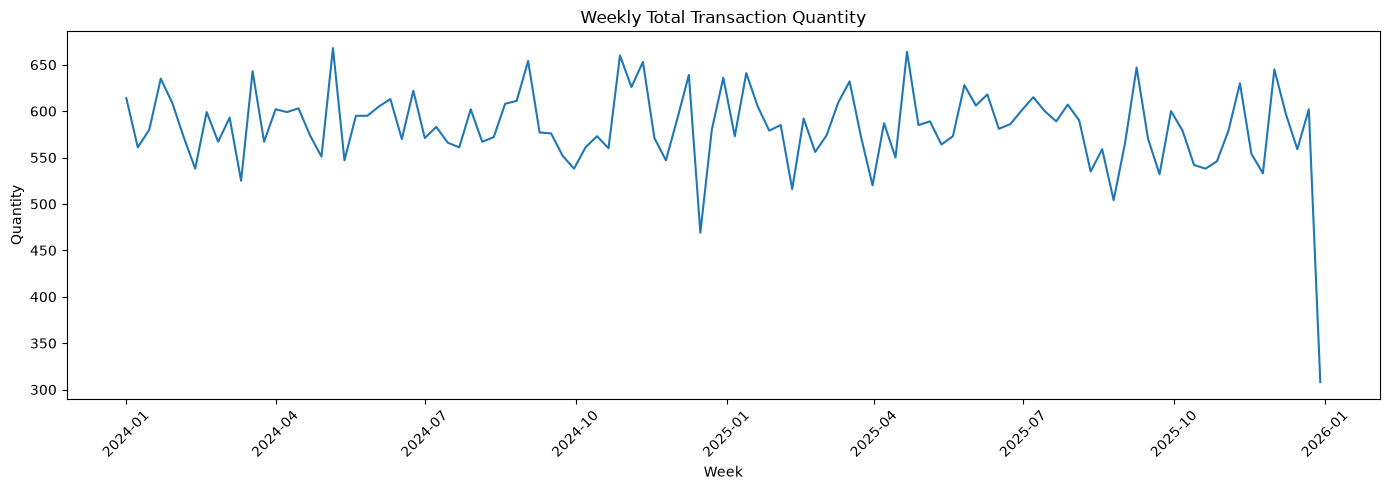

In [21]:
# 9. WEEKLY DEMAND VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    weekly_total.index,
    weekly_total["total_quantity"]
)

plt.title("Weekly Total Transaction Quantity")
plt.xlabel("Week")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()